In [7]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [3]:
import pandas as pd

train = pd.read_parquet("outputs/eda/train_processed.parquet")

X = train.drop(columns=["TARGET", "SK_ID_CURR"])
y = train["TARGET"]

print(f"X: {X.shape}, y: {y.shape}")

X: (307511, 159), y: (307511,)


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, accuracy_score)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pipeline(pipeline, X, y, label):
    """Запускает CV и считает все метрики по каждому фолду."""
    metrics = {"roc_auc": [], "f1": [], "precision": [],
               "recall": [], "accuracy": []}
    start = time.time()

    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y)):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_prob = pipeline.predict_proba(X_val)[:, 1]
        y_pred = pipeline.predict(X_val)

        metrics["roc_auc"].append(roc_auc_score(y_val, y_prob))
        metrics["f1"].append(f1_score(y_val, y_pred))
        metrics["precision"].append(precision_score(y_val, y_pred))
        metrics["recall"].append(recall_score(y_val, y_pred))
        metrics["accuracy"].append(accuracy_score(y_val, y_pred))

        print(f"  Fold {fold+1}/5 — "
              f"AUC={metrics['roc_auc'][-1]:.4f}  "
              f"F1={metrics['f1'][-1]:.4f}  "
              f"({(time.time()-start)/60:.1f} min)")

    # Итог
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    for metric, values in metrics.items():
        print(f"  {metric:<12}: {np.mean(values):.4f} ± {np.std(values):.4f}")

    return {k: np.mean(v) for k, v in metrics.items()}

all_results = {}

In [8]:
print("Running: Baseline...")
pipe_baseline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(C=0.1, max_iter=1000, class_weight="balanced",
                                   solver="saga", random_state=42, n_jobs=-1))
])
all_results["Baseline"] = evaluate_pipeline(pipe_baseline, X, y, "Baseline (L2, C=0.1)")

Running: Baseline...
  Fold 1/5 — AUC=0.7582  F1=0.2694  (6.1 min)
  Fold 2/5 — AUC=0.7700  F1=0.2743  (12.2 min)
  Fold 3/5 — AUC=0.7655  F1=0.2714  (18.1 min)
  Fold 4/5 — AUC=0.7685  F1=0.2755  (23.6 min)
  Fold 5/5 — AUC=0.7610  F1=0.2687  (29.6 min)

  Baseline (L2, C=0.1)
  roc_auc     : 0.7646 ± 0.0045
  f1          : 0.2719 ± 0.0026
  precision   : 0.1690 ± 0.0017
  recall      : 0.6955 ± 0.0080
  accuracy    : 0.6992 ± 0.0023
  Time       : 29.6 min


In [13]:
print("Running: SMOTE...")

pipe_smote = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(random_state=42)),                    
    ("model",   LogisticRegression(
        C=0.1,
        max_iter=2000,                  
        solver="saga",
        random_state=42,
        n_jobs=-1
    ))
])

all_results["SMOTE"] = evaluate_pipeline(
    pipeline=pipe_smote, 
    X=X, 
    y=y, 
    label="SMOTE + L2 C=0.1"
)

Running: SMOTE...
  Fold 1/5 — AUC=0.7505  F1=0.2684  (95.2 min)
  Fold 2/5 — AUC=0.7592  F1=0.2713  (163.4 min)
  Fold 3/5 — AUC=0.7575  F1=0.2679  (194.5 min)
  Fold 4/5 — AUC=0.7604  F1=0.2730  (219.0 min)
  Fold 5/5 — AUC=0.7541  F1=0.2694  (243.7 min)

  SMOTE + L2 C=0.1
  roc_auc     : 0.7563 ± 0.0036
  f1          : 0.2700 ± 0.0019
  precision   : 0.1687 ± 0.0013
  recall      : 0.6754 ± 0.0052
  accuracy    : 0.7052 ± 0.0024
  Time       : 243.7 min


In [23]:
print("Running: SMOTE + ElasticNet Logistic Regression...")

X_small = X.sample(100000, random_state=42)
y_small = y.loc[X_small.index]

pipe_smote_enet = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTE(k_neighbors=3, random_state=42)),
    ("model",   LogisticRegression(
        penalty="elasticnet",
        l1_ratio=0.5,        
        C=0.1,
        solver="saga",       
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    ))
])

all_results["SMOTE_ElasticNet"] = evaluate_pipeline(
    pipeline=pipe_smote_enet,
    X=X_small,
    y=y_small,
    label="SMOTE + ElasticNet"
)

Running: SMOTE + ElasticNet Logistic Regression...
  Fold 1/5 — AUC=0.7517  F1=0.2669  (3.8 min)
  Fold 2/5 — AUC=0.7529  F1=0.2691  (7.5 min)
  Fold 3/5 — AUC=0.7576  F1=0.2704  (11.3 min)
  Fold 4/5 — AUC=0.7578  F1=0.2704  (15.2 min)
  Fold 5/5 — AUC=0.7534  F1=0.2691  (19.1 min)

  SMOTE + ElasticNet
  roc_auc     : 0.7547 ± 0.0025
  f1          : 0.2692 ± 0.0013
  precision   : 0.1684 ± 0.0010
  recall      : 0.6713 ± 0.0021
  accuracy    : 0.7081 ± 0.0021
  Time       : 19.1 min


In [25]:
print("Running: SMOTE + TomekLinks...")

from imblearn.combine import SMOTETomek

pipe_smote_tomek = ImbPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("smote",   SMOTETomek(random_state=42)),
    ("model",   LogisticRegression(
        C=0.1,
        solver="lbfgs",
        max_iter=500,
        n_jobs=-1,
        random_state=42
    ))
])

all_results["SMOTE_Tomek"] = evaluate_pipeline(
    pipeline=pipe_smote_tomek,
    X=X_small,
    y=y_small,
    label="SMOTE + TomekLinks"
)

Running: SMOTE + TomekLinks...
  Fold 1/5 — AUC=0.7516  F1=0.2677  (0.7 min)
  Fold 2/5 — AUC=0.7531  F1=0.2678  (1.3 min)
  Fold 3/5 — AUC=0.7579  F1=0.2699  (1.9 min)
  Fold 4/5 — AUC=0.7579  F1=0.2711  (2.5 min)
  Fold 5/5 — AUC=0.7535  F1=0.2678  (3.2 min)

  SMOTE + TomekLinks
  roc_auc     : 0.7548 ± 0.0026
  f1          : 0.2689 ± 0.0014
  precision   : 0.1681 ± 0.0009
  recall      : 0.6710 ± 0.0054
  accuracy    : 0.7077 ± 0.0021
  Time       : 3.2 min


In [27]:
summary = pd.DataFrame(all_results).T
summary.index.name = "Model"
summary = summary[["roc_auc", "f1", "precision", "recall", "accuracy"]]
summary.columns = ["ROC-AUC", "F1", "Precision", "Recall", "Accuracy"]

print("\n" + "="*65)
print("  FINAL COMPARISON")
print("="*65)
print(summary.round(4).to_string())

summary.to_csv("logistic_regression_results.csv")
print("\nSaved → logistic_regression_results.csv")


  FINAL COMPARISON
                  ROC-AUC      F1  Precision  Recall  Accuracy
Model                                                         
Baseline           0.7646  0.2719     0.1690  0.6955    0.6992
SMOTE              0.7563  0.2700     0.1687  0.6754    0.7052
SMOTE_ElasticNet   0.7547  0.2692     0.1684  0.6713    0.7081
SMOTE_Tomek        0.7548  0.2689     0.1681  0.6710    0.7077

Saved → logistic_regression_results.csv


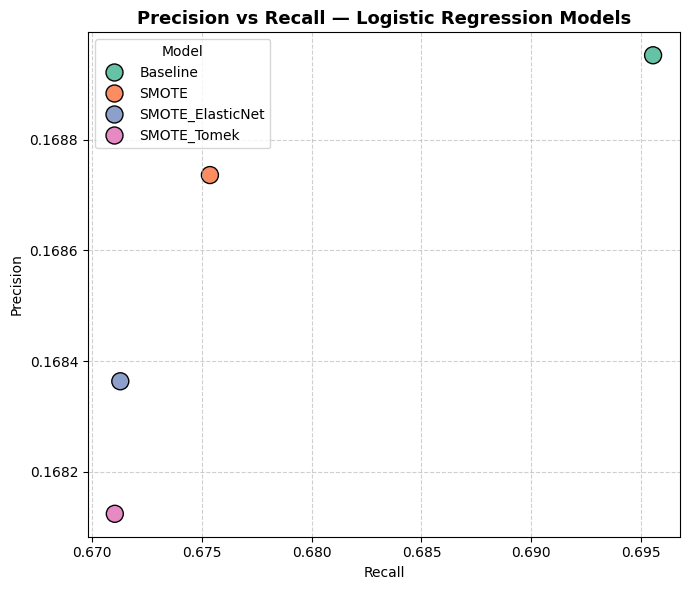

In [41]:
plt.figure(figsize=(7, 6))

sns.scatterplot(data=df, x='Recall', y='Precision', hue='Model', s=150, palette='Set2', edgecolor='black')

plt.title('Precision vs Recall — Logistic Regression Models', fontsize=13, fontweight='bold')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('logreg_precision_recall.png', dpi=200)
plt.show()

<Figure size 900x500 with 0 Axes>

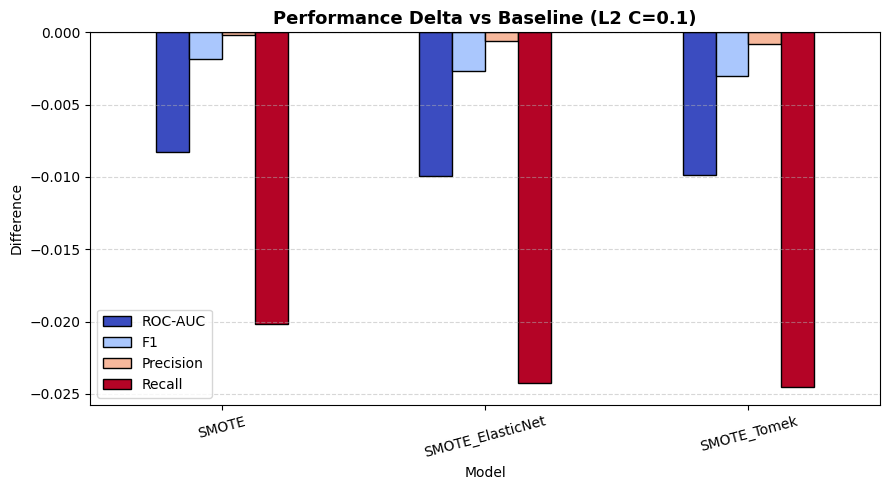

In [42]:
baseline = df.iloc[0][['ROC-AUC', 'F1', 'Precision', 'Recall']]

delta = df.set_index('Model')[['ROC-AUC', 'F1', 'Precision', 'Recall']] - baseline

delta = delta.drop('Baseline')

plt.figure(figsize=(9, 5))
delta.plot(kind='bar', figsize=(9, 5), colormap='coolwarm', edgecolor='black')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Performance Delta vs Baseline (L2 C=0.1)', fontsize=13, fontweight='bold')
plt.ylabel('Difference')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('logreg_delta.png', dpi=200)
plt.show()